In [31]:
print("Hello")

Hello


# Career Progression and Promotion Gap Analysis

## 1. Project Introduction

This project analyzes employee career progression, promotion gaps,
career stagnation, training participation, and potential retention
opportunities using employee HR data.

The project uses Python, machine learning, Power BI, and Streamlit.

# 2. Import Libraries

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

# 3. Load Dataset

In [33]:
df = pd.read_csv("/content/Palo Alto Networks.csv")

print("Dataset Shape:", df.shape)

Dataset Shape: (1470, 31)


In [34]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [35]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

# 4. Dataset Overview

In [36]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 1470
Number of Columns: 31


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   int64 
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

In [38]:
df.describe()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,0.161224,802.485714,9.192517,2.912925,2.721769,65.891156,2.729932,2.063946,2.728571,...,3.153741,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,0.367863,403.509100,8.106864,1.024165,1.093082,20.329428,0.711561,1.106940,1.102846,...,0.360824,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,0.000000,102.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,...,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,0.000000,465.000000,2.000000,2.000000,2.000000,48.000000,2.000000,1.000000,2.000000,...,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,0.000000,802.000000,7.000000,3.000000,3.000000,66.000000,3.000000,2.000000,3.000000,...,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,0.000000,1157.000000,14.000000,4.000000,4.000000,83.750000,3.000000,3.000000,4.000000,...,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1.000000,1499.000000,29.000000,5.000000,4.000000,100.000000,4.000000,5.000000,4.000000,...,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


# 5. Data Quality Check

In [39]:
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

Missing Values: 0
Duplicate Rows: 0


In [40]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EnvironmentSatisfaction,0
Gender,0


# 6. Exploratory Data Analysis

In [41]:
df["Attrition"].value_counts()

,count
Attrition,
0,1233
1,237


In [42]:
attrition_rate = df["Attrition"].mean() * 100

print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.12%


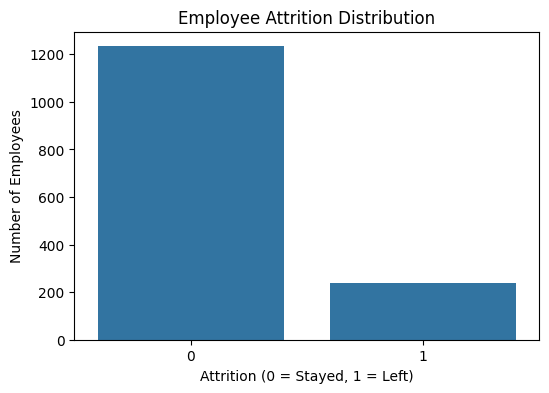

In [43]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Attrition"
)

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition (0 = Stayed, 1 = Left)")
plt.ylabel("Number of Employees")

plt.show()

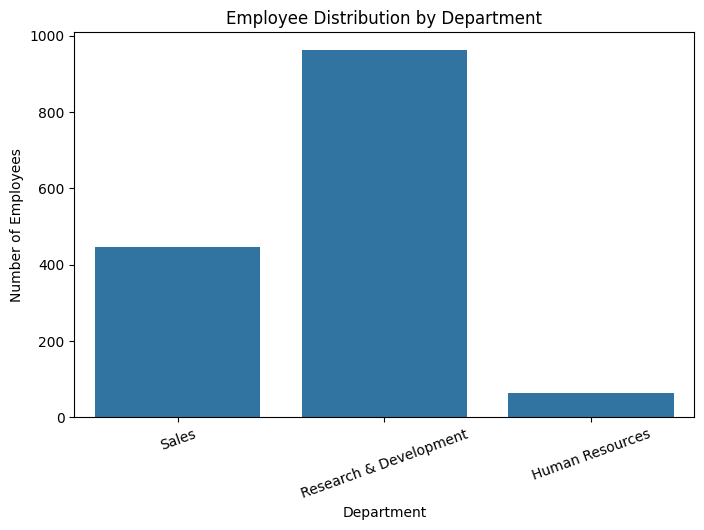

In [44]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Department"
)

plt.title("Employee Distribution by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")

plt.xticks(rotation=20)

plt.show()

# 7. Career Progression Analysis

In [45]:
career_features = [
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager",
    "TrainingTimesLastYear"
]

df[career_features].describe()

,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TrainingTimesLastYear
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,7.008163,4.229252,2.187755,4.123129,2.799320
std,6.126525,3.623137,3.222430,3.568136,1.289271
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,2.000000,0.000000,2.000000,2.000000
50%,5.000000,3.000000,1.000000,3.000000,3.000000
75%,9.000000,7.000000,3.000000,7.000000,3.000000
max,40.000000,18.000000,15.000000,17.000000,6.000000


In [46]:
df.groupby("Attrition")[
    [
        "YearsAtCompany",
        "YearsInCurrentRole",
        "YearsSinceLastPromotion",
        "YearsWithCurrManager",
        "TrainingTimesLastYear"
    ]
].mean()

,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TrainingTimesLastYear
Attrition,,,,,
0,7.369019,4.484185,2.234388,4.367397,2.832928
1,5.130802,2.902954,1.945148,2.852321,2.624473


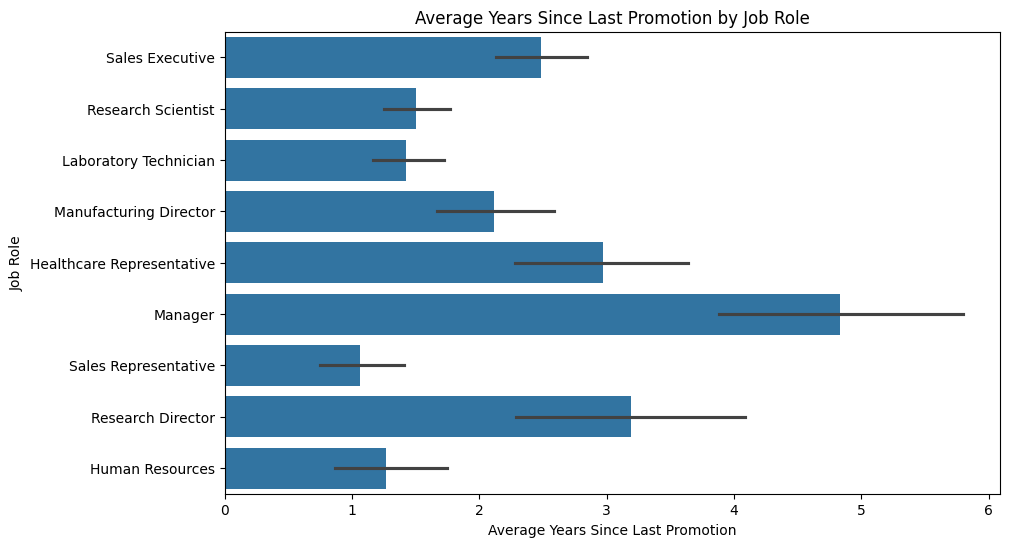

In [47]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="YearsSinceLastPromotion",
    y="JobRole",
    estimator="mean"
)

plt.title("Average Years Since Last Promotion by Job Role")
plt.xlabel("Average Years Since Last Promotion")
plt.ylabel("Job Role")

plt.show()

# 8. Feature Engineering

In [48]:
df["PromotionGapRatio"] = (
    df["YearsSinceLastPromotion"] /
    df["YearsAtCompany"].replace(0, 1)
)

In [49]:
df["RoleStagnationIndex"] = (
    df["YearsInCurrentRole"] /
    df["YearsAtCompany"].replace(0, 1)
)

In [50]:
df["TrainingIntensity"] = (
    df["TrainingTimesLastYear"] /
    df["YearsAtCompany"].replace(0, 1)
)

In [51]:
df["ManagerStabilityRatio"] = (
    df["YearsWithCurrManager"] /
    df["YearsAtCompany"].replace(0, 1)
)

In [52]:
df[
    [
        "PromotionGapRatio",
        "RoleStagnationIndex",
        "TrainingIntensity",
        "ManagerStabilityRatio"
    ]
].head()

,PromotionGapRatio,RoleStagnationIndex,TrainingIntensity,ManagerStabilityRatio
0,0.000,0.666667,0.000,0.833333
1,0.100,0.700000,0.300,0.700000
2,0.000,0.000000,3.000,0.000000
3,0.375,0.875000,0.375,0.000000
4,1.000,1.000000,1.500,1.000000


# 9. Career Clustering

In [53]:
cluster_features = [
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager",
    "TrainingTimesLastYear",
    "JobLevel",
    "TotalWorkingYears"
]

In [54]:
X = df[cluster_features]

In [55]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [56]:
inertia = []

for k in range(2, 9):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

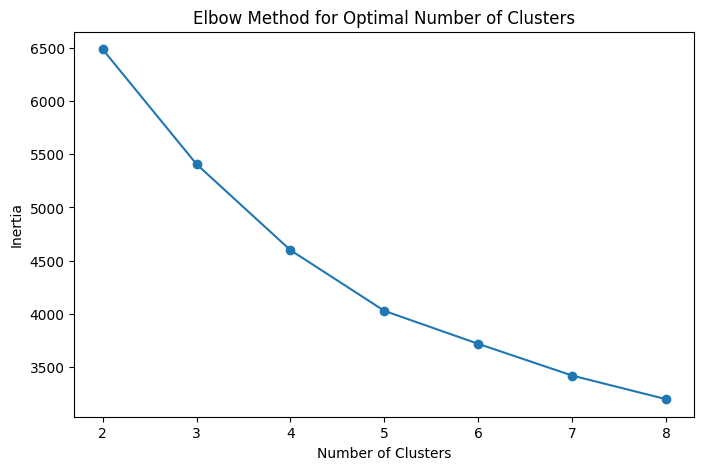

In [57]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,9),
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

In [58]:
for k in range(2, 8):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    print(
        f"K={k} | Silhouette Score={score:.3f}"
    )

K=2 | Silhouette Score=0.370
K=3 | Silhouette Score=0.306
K=4 | Silhouette Score=0.327
K=5 | Silhouette Score=0.286
K=6 | Silhouette Score=0.285
K=7 | Silhouette Score=0.271


In [59]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

df["CareerCluster"] = kmeans.fit_predict(X_scaled)

In [60]:
cluster_profile = df.groupby(
    "CareerCluster"
)[cluster_features].mean()

cluster_profile

,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TrainingTimesLastYear,JobLevel,TotalWorkingYears
CareerCluster,,,,,,,
0,3.855819,2.282183,0.782698,2.247168,2.770340,1.646756,8.106076
1,13.142285,8.018036,4.921844,7.773547,2.855711,2.875752,17.454910


In [61]:
cluster_profile = df.groupby(
    "CareerCluster"
)[cluster_features].mean()

cluster_profile

,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TrainingTimesLastYear,JobLevel,TotalWorkingYears
CareerCluster,,,,,,,
0,3.855819,2.282183,0.782698,2.247168,2.770340,1.646756,8.106076
1,13.142285,8.018036,4.921844,7.773547,2.855711,2.875752,17.454910


# 10. Promotion Gap Scoring

In [62]:


from sklearn.preprocessing import MinMaxScaler

score_features = [
    "YearsSinceLastPromotion",
    "PromotionGapRatio",
    "RoleStagnationIndex"
]

score_scaler = MinMaxScaler()

df[
    [
        "PromotionGap_Norm",
        "PromotionGapRatio_Norm",
        "RoleStagnation_Norm"
    ]
] = score_scaler.fit_transform(
    df[score_features]
)

df["PromotionGapScore"] = (
    df["PromotionGap_Norm"] * 0.40 +
    df["PromotionGapRatio_Norm"] * 0.30 +
    df["RoleStagnation_Norm"] * 0.30
)

df[[
    "YearsSinceLastPromotion",
    "PromotionGapRatio",
    "RoleStagnationIndex",
    "PromotionGapScore"
]].head()

,YearsSinceLastPromotion,PromotionGapRatio,RoleStagnationIndex,PromotionGapScore
0,0,0.000,0.666667,0.200000
1,1,0.100,0.700000,0.266667
2,0,0.000,0.000000,0.000000
3,3,0.375,0.875000,0.455000
4,2,1.000,1.000000,0.653333


In [63]:
df["PromotionGapLevel"] = pd.qcut(
    df["PromotionGapScore"],
    q=3,
    labels=["Low", "Medium", "High"]
)

print(df["PromotionGapLevel"].value_counts())

PromotionGapLevel
Low       490
Medium    490
High      490
Name: count, dtype: int64


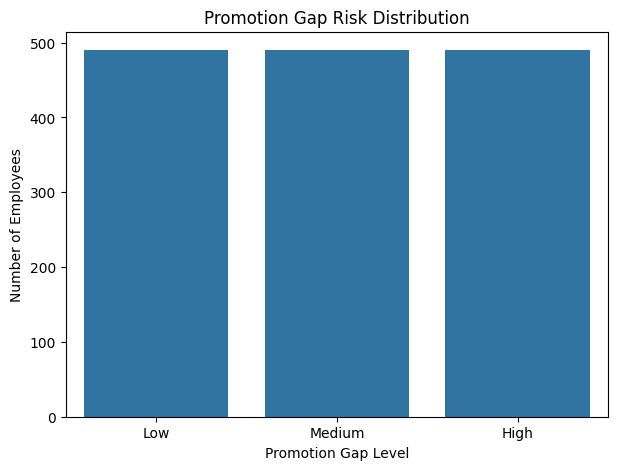

In [64]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="PromotionGapLevel",
    order=["Low", "Medium", "High"]
)

plt.title("Promotion Gap Risk Distribution")
plt.xlabel("Promotion Gap Level")
plt.ylabel("Number of Employees")

plt.show()

In [65]:
cluster_promotion = pd.crosstab(
    df["CareerCluster"],
    df["PromotionGapLevel"],
    normalize="index"
) * 100

cluster_promotion

PromotionGapLevel,Low,Medium,High
CareerCluster,,,
0,44.387230,37.590113,18.022657
1,11.823647,25.050100,63.126253


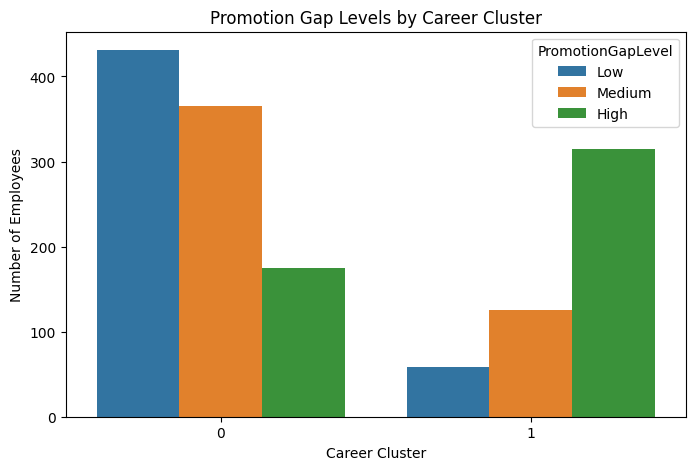

In [66]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="CareerCluster",
    hue="PromotionGapLevel",
    order=[0, 1],
    hue_order=["Low", "Medium", "High"]
)

plt.title("Promotion Gap Levels by Career Cluster")
plt.xlabel("Career Cluster")
plt.ylabel("Number of Employees")

plt.show()

# 11. Retention Opportunity Identification

In [67]:
df["RetentionOpportunity"] = np.where(
    (
        (df["PromotionGapLevel"] == "High") &
        (df["Attrition"] == 0) &
        (df["JobSatisfaction"] >= 3)
    ),
    "Yes",
    "No"
)

print(df["RetentionOpportunity"].value_counts())

RetentionOpportunity
No     1210
Yes     260
Name: count, dtype: int64


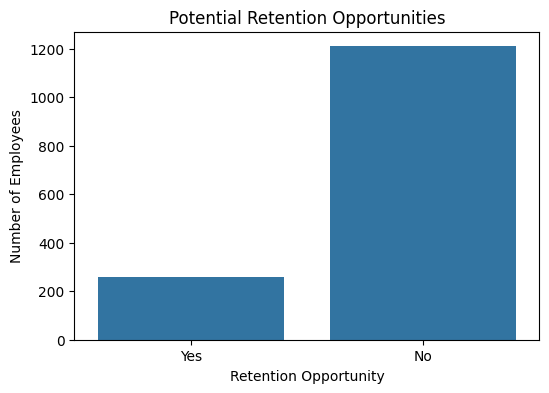

In [68]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="RetentionOpportunity",
    order=["Yes", "No"]
)

plt.title("Potential Retention Opportunities")
plt.xlabel("Retention Opportunity")
plt.ylabel("Number of Employees")

plt.show()

In [69]:
df["TrainingNeed"] = np.where(
    (
        (df["PromotionGapLevel"] == "High") &
        (df["TrainingTimesLastYear"] <= 2)
    ),
    "Yes",
    "No"
)

print(df["TrainingNeed"].value_counts())

TrainingNeed
No     1244
Yes     226
Name: count, dtype: int64


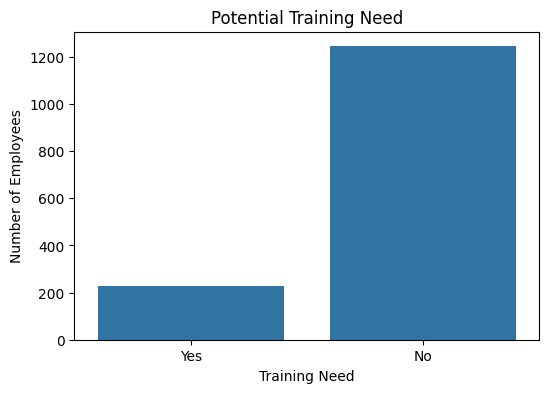

In [70]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="TrainingNeed",
    order=["Yes", "No"]
)

plt.title("Potential Training Need")
plt.xlabel("Training Need")
plt.ylabel("Number of Employees")

plt.show()

In [71]:
retention_department = pd.crosstab(
    df["Department"],
    df["RetentionOpportunity"]
)

retention_department

RetentionOpportunity,No,Yes
Department,,
Human Resources,52,11
Research & Development,789,172
Sales,369,77


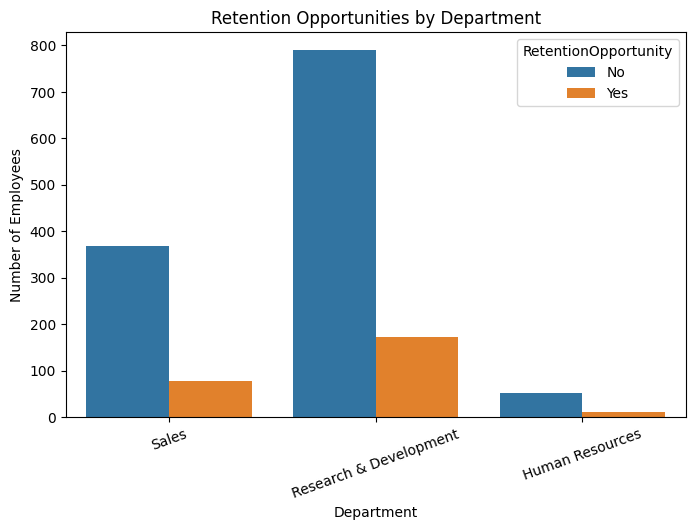

In [72]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Department",
    hue="RetentionOpportunity",
    hue_order=["No", "Yes"]
)

plt.title("Retention Opportunities by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")

plt.xticks(rotation=20)

plt.show()

In [73]:
retention_employees = df[
    df["RetentionOpportunity"] == "Yes"
][
    [
        "Age",
        "Department",
        "JobRole",
        "JobLevel",
        "YearsAtCompany",
        "YearsInCurrentRole",
        "YearsSinceLastPromotion",
        "YearsWithCurrManager",
        "TrainingTimesLastYear",
        "CareerCluster",
        "PromotionGapScore",
        "PromotionGapLevel",
        "TrainingNeed",
        "JobSatisfaction"
    ]
]

retention_employees.head(20)

,Age,Department,JobRole,JobLevel,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TrainingTimesLastYear,CareerCluster,PromotionGapScore,PromotionGapLevel,TrainingNeed,JobSatisfaction
3,33,Research & Development,Research Scientist,1,8,7,3,0,3,0,0.455000,High,No,3
5,32,Research & Development,Laboratory Technician,1,7,7,3,6,2,0,0.508571,High,Yes,4
9,36,Research & Development,Healthcare Representative,2,7,7,7,7,3,1,0.786667,High,No,3
12,31,Research & Development,Research Scientist,1,5,2,4,3,1,0,0.466667,High,Yes,3
13,34,Research & Development,Laboratory Technician,1,2,2,1,2,2,0,0.476667,High,Yes,4
25,53,Research & Development,Manager,5,14,13,4,8,3,1,0.470952,High,No,3
37,35,Sales,Sales Representative,1,2,2,2,2,3,0,0.653333,High,No,4
44,30,Research & Development,Laboratory Technician,2,12,8,3,7,2,1,0.355000,High,Yes,4
46,34,Sales,Sales Executive,2,9,5,8,7,2,1,0.646667,High,Yes,3
55,33,Research & Development,Research Director,3,15,14,8,12,1,1,0.653333,High,Yes,4


In [74]:
pd.crosstab(
    df["CareerCluster"],
    df["RetentionOpportunity"]
)

RetentionOpportunity,No,Yes
CareerCluster,,
0,878,93
1,332,167


# 12. Final Dataset

In [75]:
df.to_csv(
    "Palo_Alto_Career_Progression_Final.csv",
    index=False
)

print("Final dataset saved successfully!")

Final dataset saved successfully!
